In [4]:
# Paste this cell into your notebook and run.
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import joblib

# --------- user-editable paths (change as needed) ----------
CSV_PATH = r"C:\Users\shiva\OneDrive\Desktop\MASK-R-CNN-Vision-Biology-Lab\analysis\GB_training_data.csv"               # <- change if your CSV is elsewhere
MODEL_SAVE_PATH = r"GB_model_v1_unscaled.joblib"  # <- where the GB model will be saved
FIGURES_DIR = r"/mnt/data/gb_figures"                      # <- folder to save generated plots
os.makedirs(FIGURES_DIR, exist_ok=True)

# --------- feature / label columns expected in your CSV ----------
feature_cols = [
    "original_area",
    "aspect_ratio",
    "circularity",
    "solidity",
    "mean_intensity",
    "std_intensity",
    "mrcnn_prob_other",
    "mrcnn_prob_rbc",
    "mrcnn_prob_cbc"
]
label_col = "gt_label"   # expected label column in the CSV (0,1,2 as in your pipeline)


Loaded CSV with shape: (26366, 16)
After dropping NaNs shape: (26366, 10)
Saved boxplots to /mnt/data/gb_figures\feature_boxplots_by_class.png


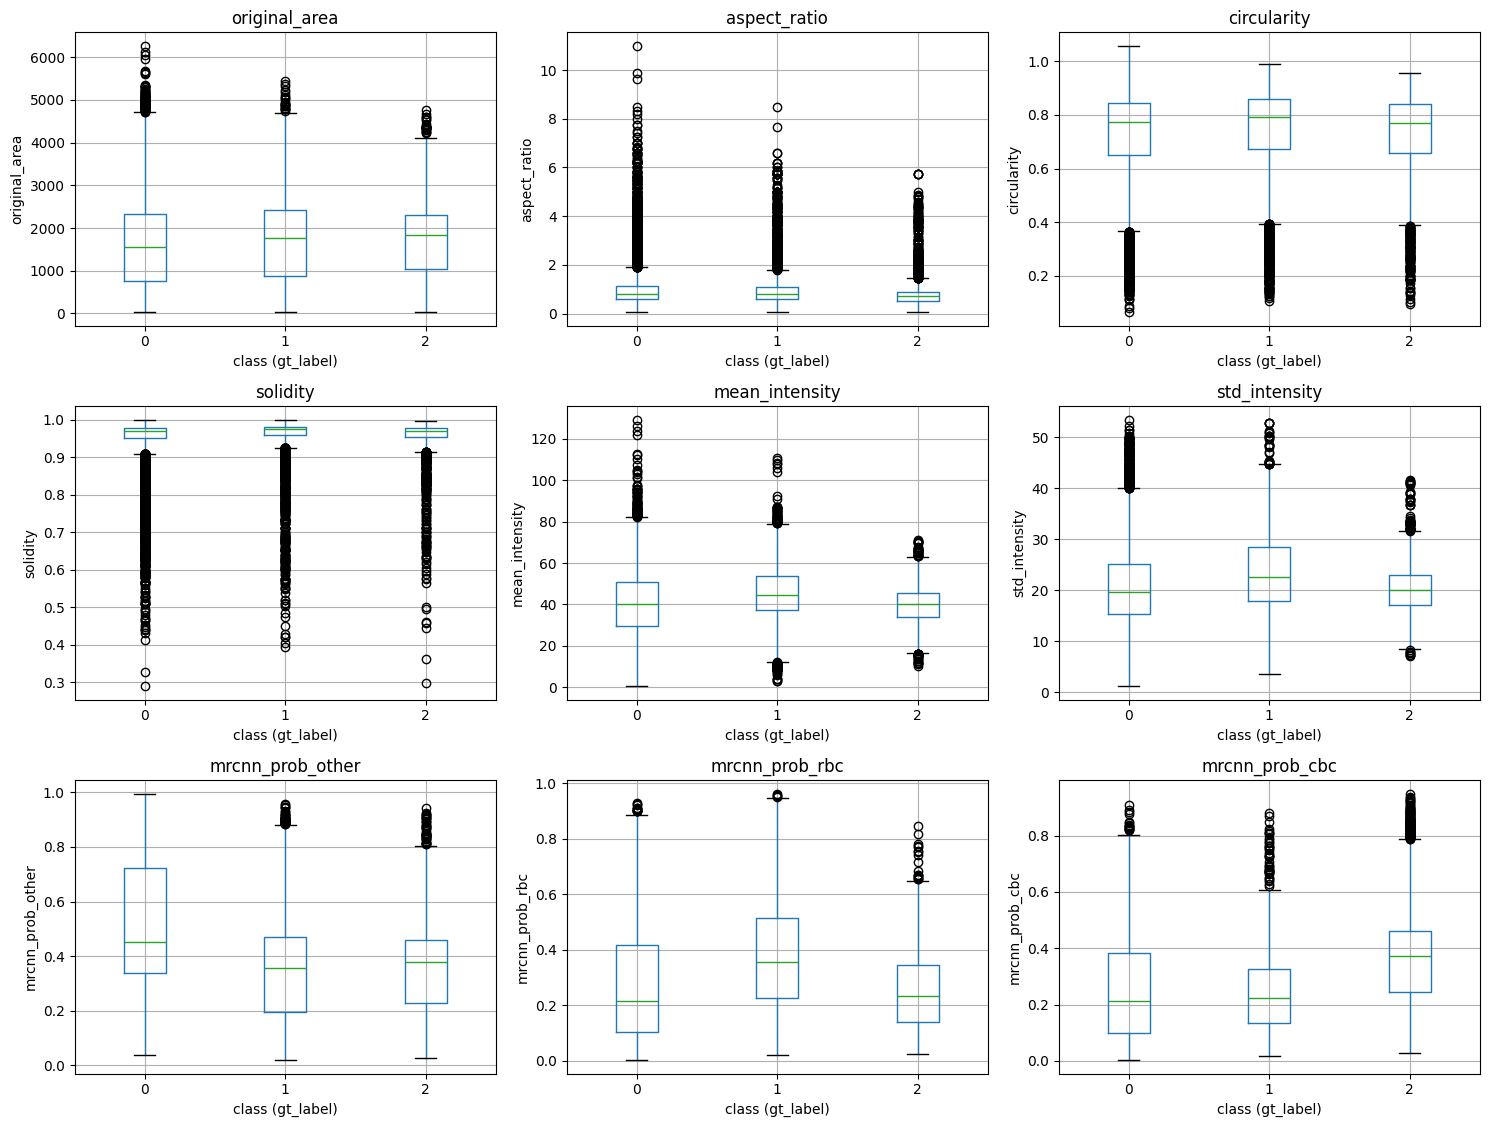

In [5]:

# --------- load CSV and basic checks ----------
df = pd.read_csv(CSV_PATH)
print("Loaded CSV with shape:", df.shape)
missing = [c for c in feature_cols + [label_col] if c not in df.columns]
if missing:
    raise ValueError(f"The following required columns are missing from the CSV: {missing}")

# drop rows with NaNs in our selected cols (or you can impute)
df = df[feature_cols + [label_col]].dropna().reset_index(drop=True)
print("After dropping NaNs shape:", df.shape)
X = df[feature_cols].values
y = df[label_col].values.astype(int)

# ---------- 1) Boxplots of each feature grouped by class ----------
plt.rcParams.update({"figure.max_open_warning": 0})
n_features = len(feature_cols)
ncols = 3
nrows = int(np.ceil(n_features / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
axes = axes.ravel()
for i, feat in enumerate(feature_cols):
    # use pandas boxplot grouped by label for convenience
    df_box = df[[feat, label_col]].copy()
    # convert label to string for nicer xticks
    df_box[label_col] = df_box[label_col].astype(str)
    df_box.boxplot(by=label_col, column=feat, ax=axes[i])
    axes[i].set_title(feat)
    axes[i].set_xlabel("class (gt_label)")
    axes[i].set_ylabel(feat)
# hide empty subplots
for j in range(n_features, len(axes)):
    fig.delaxes(axes[j])
plt.suptitle("")  # remove pandas auto-title
plt.tight_layout(rect=[0,0,1,0.96])
boxplot_file = os.path.join(FIGURES_DIR, "feature_boxplots_by_class.png")
plt.savefig(boxplot_file, dpi=150)
print("Saved boxplots to", boxplot_file)
plt.show()



PCA explained variance ratios (2 comps): [0.23948449 0.22979041]
Saved PCA scatter to /mnt/data/gb_figures\pca_2d_by_class.png


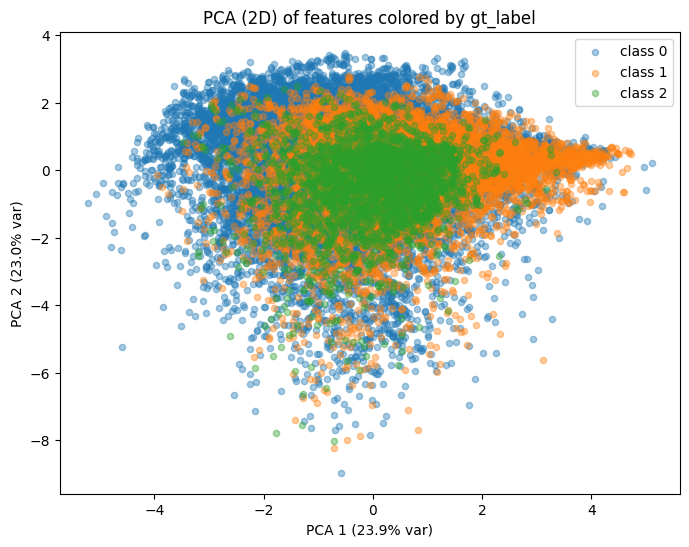

In [6]:
# ---------- 2) PCA on the features and 2D visualization ----------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
explained = pca.explained_variance_ratio_
print(f"PCA explained variance ratios (2 comps): {explained}")

plt.figure(figsize=(8,6))
classes = np.unique(y)
colors = ["C0", "C1", "C2", "C3", "C4"]  # extend if more classes
for c_idx, c in enumerate(classes):
    mask = (y == c)
    plt.scatter(X_pca[mask,0], X_pca[mask,1], s=20, alpha=0.4, label=f"class {c}", color=colors[c_idx % len(colors)])
plt.xlabel(f"PCA 1 ({explained[0]*100:.1f}% var)")
plt.ylabel(f"PCA 2 ({explained[1]*100:.1f}% var)")
plt.legend()
plt.title("PCA (2D) of features colored by gt_label")
pca_file = os.path.join(FIGURES_DIR, "pca_2d_by_class.png")
plt.savefig(pca_file, dpi=150)
print("Saved PCA scatter to", pca_file)
plt.show()


In [7]:
# ---------- 3) Train/test split ----------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

# Note: Gradient Boosting works fine without scaling, but we show scaler usage if needed.
# We'll train on raw features (as is). If you prefer scaled features, uncomment the scaler transform:
# scaler_gb = StandardScaler().fit(X_train)
# X_train_scaled = scaler_gb.transform(X_train)
# X_test_scaled = scaler_gb.transform(X_test)

# ---------- 4) Train Gradient Boosting classifier ----------
gb = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)
gb.fit(X_train, y_train)
print("Trained GradientBoostingClassifier")


Train shape: (21092, 9) Test shape: (5274, 9)
Trained GradientBoostingClassifier



Classification report (test set):

              precision    recall  f1-score   support

           0       0.68      0.93      0.79      3265
           1       0.65      0.32      0.43      1448
           2       0.71      0.17      0.28       561

    accuracy                           0.68      5274
   macro avg       0.68      0.47      0.50      5274
weighted avg       0.68      0.68      0.64      5274

Saved confusion matrix to /mnt/data/gb_figures\confusion_matrix.png


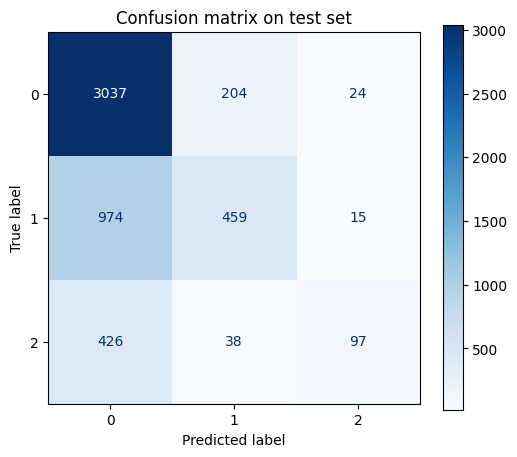

In [8]:

# ---------- 5) Evaluation ----------
y_pred = gb.predict(X_test)
print("\nClassification report (test set):\n")
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred, labels=classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[str(c) for c in classes])
fig, ax = plt.subplots(figsize=(6,5))
disp.plot(ax=ax, cmap="Blues")
plt.title("Confusion matrix on test set")
cm_file = os.path.join(FIGURES_DIR, "confusion_matrix.png")
plt.savefig(cm_file, dpi=150)
print("Saved confusion matrix to", cm_file)
plt.show()


Saved feature importances to /mnt/data/gb_figures\gb_feature_importances.png


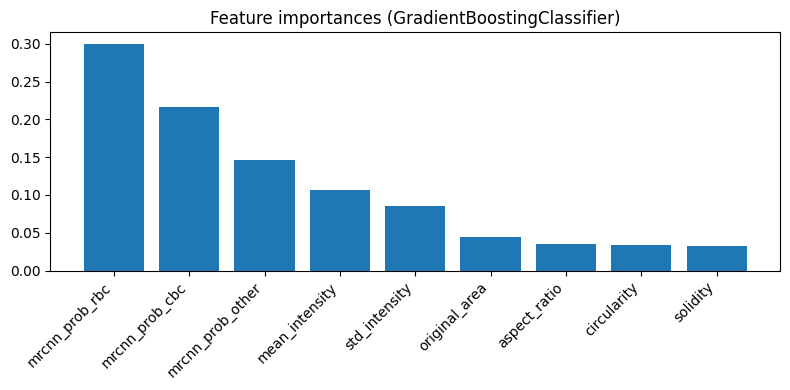

            feature  importance
7    mrcnn_prob_rbc    0.300052
8    mrcnn_prob_cbc    0.215837
6  mrcnn_prob_other    0.146429
4    mean_intensity    0.107043
5     std_intensity    0.085019
0     original_area    0.044225
1      aspect_ratio    0.035033
2       circularity    0.033252
3          solidity    0.033110
Saved trained GB model to: GB_model_v1_unscaled.joblib


In [9]:
# ---------- 6) Feature importances ----------
importances = gb.feature_importances_
feat_imp = pd.DataFrame({"feature": feature_cols, "importance": importances}).sort_values("importance", ascending=False)
plt.figure(figsize=(8,4))
plt.bar(feat_imp["feature"], feat_imp["importance"])
plt.xticks(rotation=45, ha="right")
plt.title("Feature importances (GradientBoostingClassifier)")
plt.tight_layout()
fi_file = os.path.join(FIGURES_DIR, "gb_feature_importances.png")
plt.savefig(fi_file, dpi=150)
print("Saved feature importances to", fi_file)
plt.show()
print(feat_imp)

# ---------- 7) Save trained model and (optionally) scaler ----------
joblib.dump(gb, MODEL_SAVE_PATH)
print("Saved trained GB model to:", MODEL_SAVE_PATH)

# If you used a scaler for the GB, also save it; here we saved none because GB didn't need scaling.
# joblib.dump(scaler_gb, "/path/to/scaler.joblib")
